In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns

In [45]:
from matplotlib import *

In [46]:
rcParams['pdf.fonttype']=42 # in order to save fonttype in AI
rcParams['ps.fonttype']=42

In [2]:
# 一个一个处理数据,分区域
#1，Nature  PMID: 35418686
ID35418686_Neocotex = sc.read('Cell transcriptomic atlas of the non-human primate Macaca fascicularis/Neocotex.h5ad')
ID35418686_Cerebellum = sc.read('Cell transcriptomic atlas of the non-human primate Macaca fascicularis/Cerebellum.h5ad')
ID35418686_Spinal_cord = sc.read('Cell transcriptomic atlas of the non-human primate Macaca fascicularis/Spinal_cord.h5ad')
ID35418686_Substantia_nigra = sc.read('Cell transcriptomic atlas of the non-human primate Macaca fascicularis/Substantia_nigra.h5ad')

In [3]:
# 我们的V1
FM27_v1 = sc.read('data_h5ad/FM27_cell_133454_wk_1_backup.h5')

In [4]:
FM27_v1.X = FM27_v1.layers['counts'].copy()
sc.pp.normalize_total(FM27_v1, target_sum=1e4)
sc.pp.log1p(FM27_v1)

In [5]:
# 我们的岛叶
Insular = sc.read('data_h5ad/Insular_sorted_clusters.h5ad')

In [6]:
Insular.X = Insular.layers['counts'].copy()
sc.pp.normalize_total(Insular, target_sum=1e4)
sc.pp.log1p(Insular)

In [7]:
# 我们的SNC
SNC = sc.read('I:/Monkey_Parkinson/All_single_neuclear_cell_SNC_putamen/snc_umap_fig_out.h5')

In [8]:
SNC.X = SNC.layers['counts'].copy()
sc.pp.normalize_total(SNC, target_sum=1e4)
sc.pp.log1p(SNC)

In [9]:
# 我们的Putaman
Put = sc.read('I:/Monkey_Parkinson/All_single_neuclear_cell_SNC_putamen/Figures_pipline/putamen_figout.h5')

In [10]:
Put.X = Put.layers['counts'].copy()
sc.pp.normalize_total(Put, target_sum=1e4)
sc.pp.log1p(Put)

In [11]:
# reviewer 指定要引用的文章
ad_acc = sc.read('data_processed_all/acc_label_main.h5ad')
ad_cer = sc.read('data_processed_all/cer_label_main.h5ad')
ad_cn = sc.read('data_processed_all/cn_label_main.h5ad')

In [12]:
#来一个dict把名字和anndata名字联系起来
map_dict=dict()
map_dict['Neocotex'] = ID35418686_Neocotex
map_dict['Cerebellum'] = ID35418686_Cerebellum
map_dict['Spinal_cord'] = ID35418686_Spinal_cord
map_dict['Substantia_nigra'] = ID35418686_Substantia_nigra
map_dict['V1'] = FM27_v1
map_dict['Insular'] = Insular
map_dict['SNC'] = SNC
map_dict['Put'] = Put
map_dict['ACC'] = ad_acc
map_dict['CN'] = ad_cn
map_dict['CER'] = ad_cer

In [13]:
for i in map_dict.keys():
    ad_temp = map_dict.get(i)
    sc.pp.scale(ad_temp,max_value=5)

In [14]:
# 统一名字
rename_dict = dict()
rename_dict['Oligodendrocyte']='Oligo'
rename_dict['MOL']='Oligo'
rename_dict['NFOL']='Oligo'
rename_dict['Astrocytes']='Astrocyte'
rename_dict['LAMP5 IN']='IN'
rename_dict['NPY+ LAMP5+ IN']='IN'
rename_dict['PVALB IN']='IN'
rename_dict['RELN IN']='IN'
rename_dict['SST IN']='IN'
rename_dict['VIP IN']='IN'
rename_dict['Molecular interneuron']='IN'
rename_dict['Granule cell']='Neu'
rename_dict['Motorneuron']='Neu'
rename_dict['ALDH1A1+ SOX6+ dopaminergic neuron']='Neu'
rename_dict['ALDH1A1+ SOX6-dopaminergic neuron']='Neu'
rename_dict['ALDH1A1- SOX6+ dopaminergic neuron']='Neu'
rename_dict['HTR2A IN']='IN'
rename_dict['HTR2C IN']='IN'
rename_dict['Inh']='IN'
rename_dict['Exc']='EX'
rename_dict['Exc neuron']='EX'
rename_dict['Inhib neuron']='IN'
rename_dict['Meis2 neuron']='Neu'
rename_dict['Excitatory']='EX'
rename_dict['Inhibitory']='IN'
rename_dict['GABA']='IN'
rename_dict['DaNs']='Neu'
rename_dict['HdNs']='Neu'
rename_dict['CHAT IN']='IN'
rename_dict['PVALB/TH IN']='IN'
rename_dict['SST/NPY IN']='IN'
rename_dict['dSPN']='Neu'
rename_dict['eSPN']='Neu'
rename_dict['iSPN']='Neu'

In [15]:
# 统一更改为label_main
ID35418686_Neocotex.obs['label_main'] = ID35418686_Neocotex.obs['Celltype'].copy()
ID35418686_Cerebellum.obs['label_main'] = ID35418686_Cerebellum.obs['Celltype'].copy()
ID35418686_Spinal_cord.obs['label_main'] = ID35418686_Spinal_cord.obs['Celltype'].copy()
ID35418686_Substantia_nigra.obs['label_main'] = ID35418686_Substantia_nigra.obs['Celltype'].copy()
FM27_v1.obs['label_main'] = FM27_v1.obs['class'].copy()
Insular.obs['label_main'] = Insular.obs['cellTypeLabel'].copy()
SNC.obs['label_main'] = SNC.obs['label_4'].copy()
Put.obs['label_main'] = Put.obs['label_5'].copy()

In [16]:
#只选猴子的
ad_acc = ad_acc[ad_acc.obs['orig.ident']=='M',]
ad_cn = ad_cn[ad_cn.obs['orig.ident']=='M',]
ad_cer = ad_cer[ad_cer.obs['orig.ident']=='M',]

In [17]:
common_gene = ID35418686_Neocotex.var_names
for i in map_dict.keys():
    common_gene = common_gene[common_gene.isin(map_dict.get(i).var_names)]

In [18]:
FM27_v1.obs['label_main']

GGGACCTAGATGAATC-1-23         Exc
AGAGAGCCAGGTCCGT-1-16         Exc
GTCATCCGTGTCTTGA-1-24         Exc
CTGGCAGTCTGGCCGA-1-15         Exc
CCGGACAAGACCACGA-1-17         Exc
                           ...   
TTTCCTCTCCAACCGG-1-26         OPC
TTTCGATAGACGACTG-1-26         OPC
TTTGATCAGCTGACCC-1-26         OPC
TTTGGTTAGTAATTGG-1-26    Vascular
TTTGGTTGTGTTAACC-1-26         OPC
Name: label_main, Length: 133454, dtype: category
Categories (7, object): ['Astrocyte', 'Exc', 'Inh', 'Microglia', 'OPC', 'Oligo', 'Vascular']

In [19]:
map_dict.keys()

dict_keys(['Neocotex', 'Cerebellum', 'Spinal_cord', 'Substantia_nigra', 'V1', 'Insular', 'SNC', 'Put', 'ACC', 'CN', 'CER'])

In [20]:
# 还要更具rename_dict改名
for j in map_dict.values():
    j.obs['label_main'] = j.obs['label_main'].map(lambda x:rename_dict.get(x,x))
    j.obs['label_main'] = j.obs['label_main'].astype('category')

In [35]:
df = pd.DataFrame(index=common_gene)

In [39]:
for i in ['EX','IN','Astrocyte','Oligo','OPC','Microglia']:
    for j in ['Cerebellum','CER','Spinal_cord','Neocotex','V1', 'Insular','ACC','Substantia_nigra','SNC', 'Put','CN']:
        if i in map_dict.get(j).obs['label_main'].cat.categories:
            ad_temp = map_dict.get(j)[:,common_gene]
            #sc.pp.scale(ad_temp,max_value=5)
            df_temp = ad_temp[ad_temp.obs['label_main']==i,].to_df().mean(0)
            df[j+'_'+i] = df_temp

In [40]:
plot_data = df.corr()

In [41]:
import matplotlib.pyplot as plt

In [42]:
from scipy.stats import pearsonr

<Axes: >

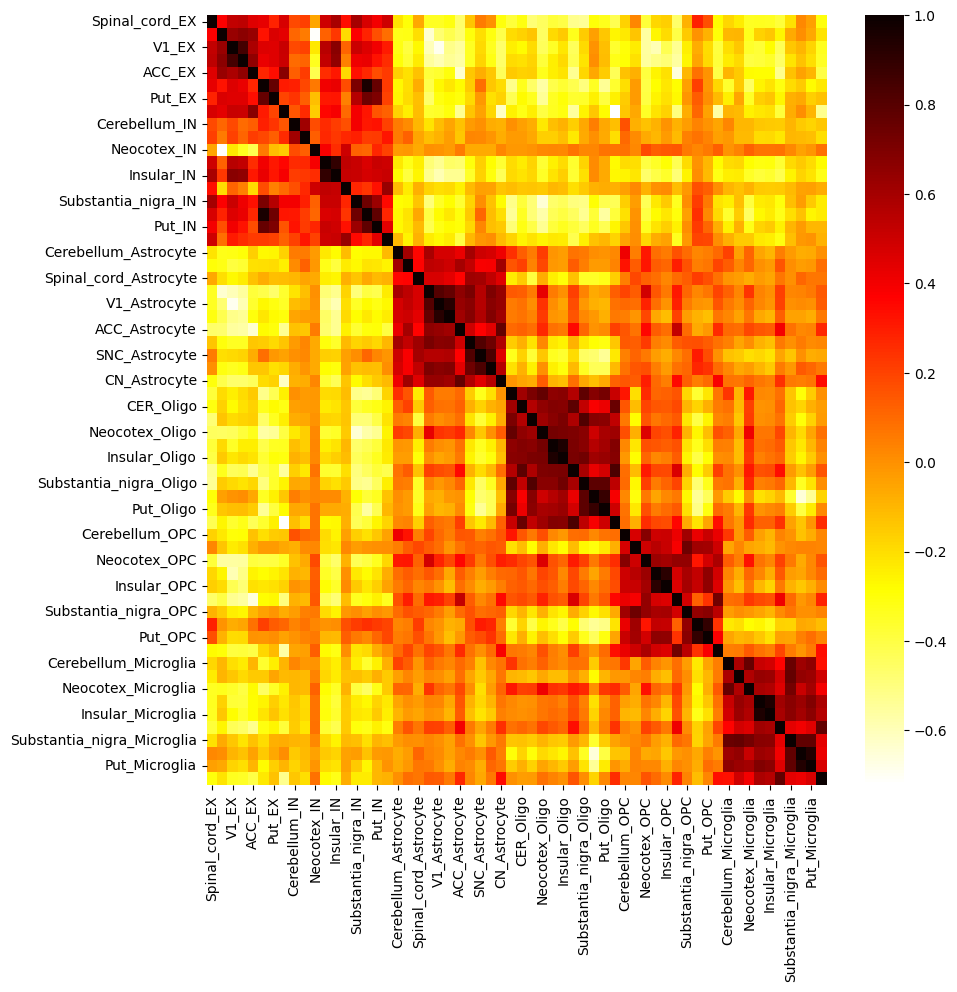

In [43]:
plt.figure(figsize=(10, 10)) 
sns.heatmap(plot_data,cmap='hot_r',)

In [60]:
plot_data

,Neocotex_EX,Spinal_cord_EX,V1_EX,Insular_EX,SNC_EX,Put_EX,ACC_EX,CN_EX,CER_EX,Neocotex_IN,...,Cerebellum_Microglia,Spinal_cord_Microglia,Substantia_nigra_Microglia,V1_Microglia,Insular_Microglia,SNC_Microglia,Put_Microglia,ACC_Microglia,CN_Microglia,CER_Microglia
Neocotex_EX,1.000000,0.377693,0.634261,0.670210,0.318948,0.461915,0.560017,0.363780,0.363780,-0.714645,...,-0.112069,-0.103684,-0.086026,-0.171338,-0.157883,-0.010040,-0.077909,0.022106,-0.154685,-0.154685
Spinal_cord_EX,0.377693,1.000000,0.523172,0.529824,0.436276,0.287867,0.352247,0.341722,0.341722,-0.037523,...,-0.190467,-0.231112,-0.215776,-0.325171,-0.342437,-0.009091,-0.069763,-0.048728,-0.185125,-0.185125
V1_EX,0.634261,0.523172,1.000000,0.841640,0.449865,0.437215,0.498863,0.425241,0.425241,-0.230283,...,-0.205051,-0.171759,-0.174154,-0.373850,-0.300724,-0.124188,-0.197472,-0.008988,-0.206267,-0.206267
Insular_EX,0.670210,0.529824,0.841640,1.000000,0.423337,0.464077,0.554288,0.417816,0.417816,-0.339652,...,-0.232534,-0.205450,-0.230899,-0.372477,-0.358780,-0.152798,-0.222035,-0.023440,-0.211242,-0.211242
SNC_EX,0.318948,0.436276,0.449865,0.423337,1.000000,0.748458,0.216908,0.238206,0.238206,0.058453,...,-0.329863,-0.174637,-0.217327,-0.259979,-0.235396,-0.171334,-0.289269,-0.029048,-0.138424,-0.138424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SNC_Microglia,-0.010040,-0.009091,-0.124188,-0.152798,-0.171334,-0.080342,-0.028380,-0.009028,-0.009028,-0.041799,...,0.643869,0.670356,0.786543,0.660622,0.646444,1.000000,0.935770,0.115766,0.183842,0.183842
Put_Microglia,-0.077909,-0.069763,-0.197472,-0.222035,-0.289269,-0.163475,-0.064838,-0.077409,-0.077409,-0.008904,...,0.687905,0.686959,0.804952,0.743527,0.719520,0.935770,1.000000,0.116858,0.229084,0.229084
ACC_Microglia,0.022106,-0.048728,-0.008988,-0.023440,-0.029048,-0.006647,0.041068,0.045088,0.045088,-0.030726,...,0.088728,0.126164,0.125201,0.141263,0.142252,0.115766,0.116858,1.000000,0.078844,0.078844
CN_Microglia,-0.154685,-0.185125,-0.206267,-0.211242,-0.138424,-0.080731,-0.222186,-0.289762,-0.289762,0.050676,...,0.184713,0.251012,0.238243,0.284297,0.276326,0.183842,0.229084,0.078844,1.000000,1.000000


<Figure size 2000x2000 with 0 Axes>

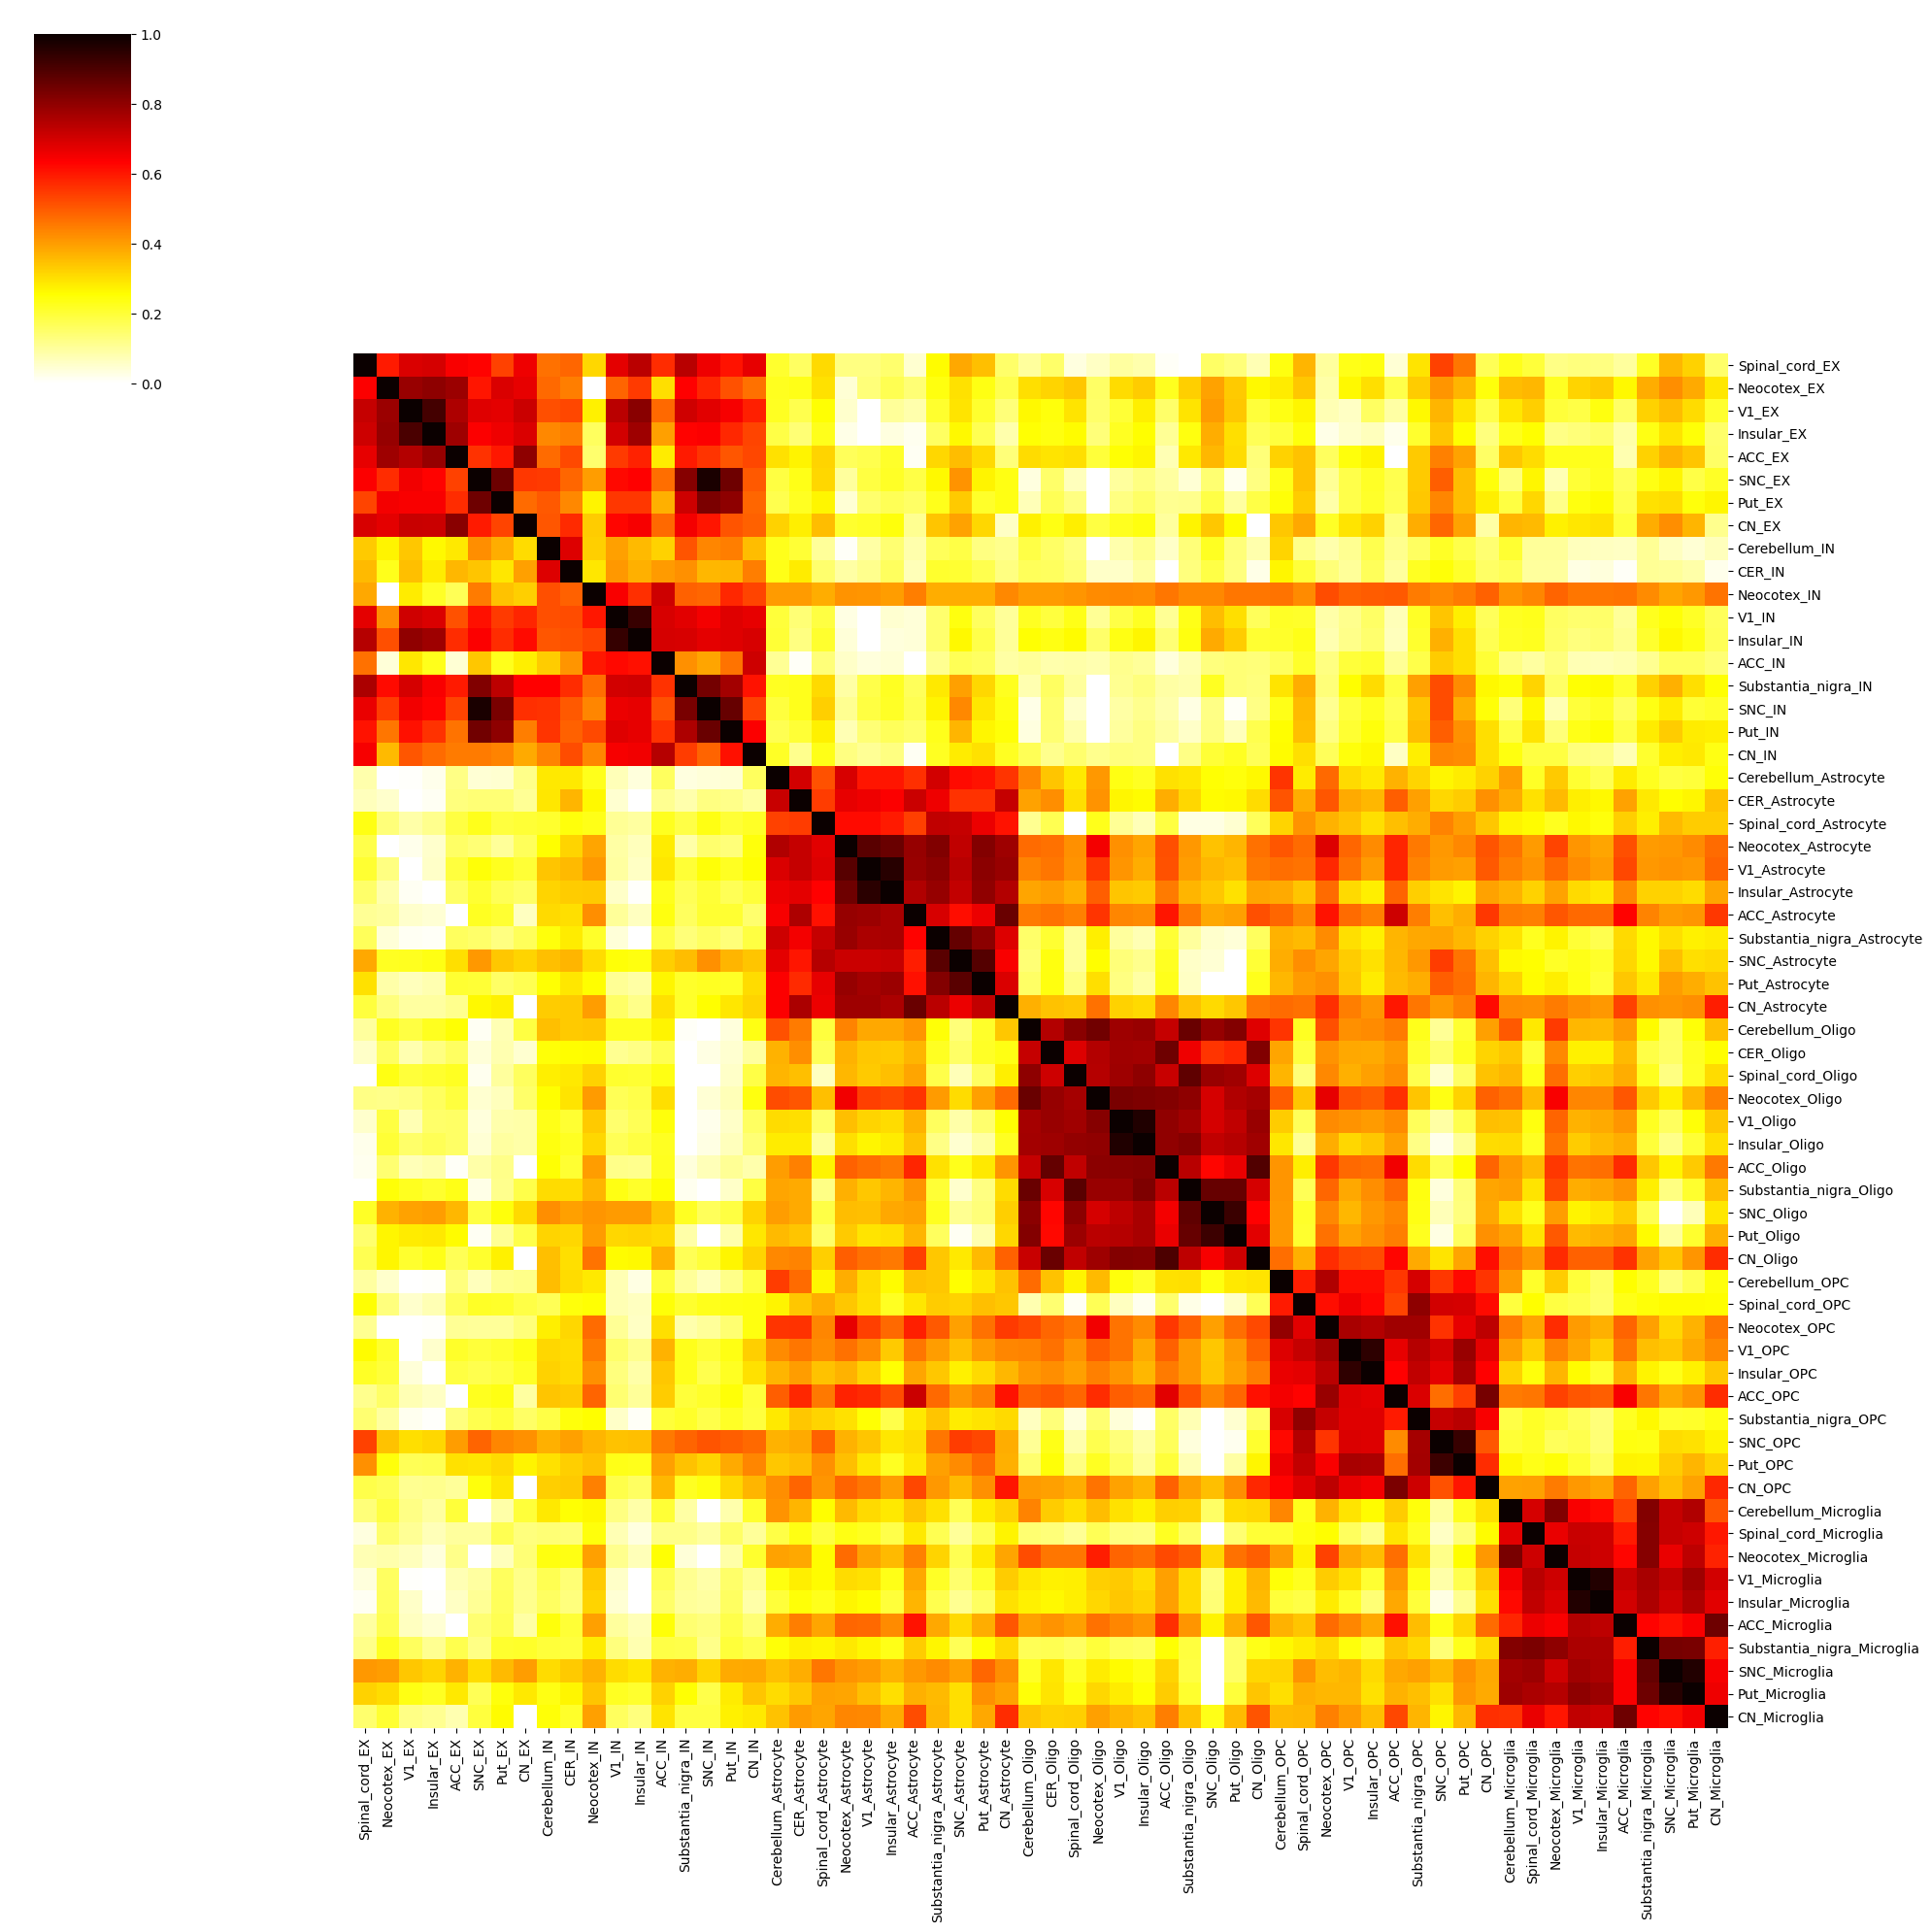

In [47]:
plt.figure(figsize=(20, 20)) 
sns.clustermap(plot_data,cmap='hot_r',standard_scale=0,row_cluster=False,col_cluster=False,figsize=(20,20))
plt.savefig('Figures/cross_region_heatmap.pdf')